Notes: demo from: 

### DDPM demo

In [1]:
# 导入 PyTorch 核心模块
import torch
import torch.nn as nn              # 神经网络层和损失函数
import torch.optim as optim        # 优化器（SGD, Adam等）

from torch.utils.data import DataLoader          # 批量数据加载器
from torchvision import datasets, transforms    # 常用数据集和图像预处理

import matplotlib.pyplot as plt    # 可视化（显示图像）

In [2]:
# 设置训练设备（GPU优先）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_size = 28           # 图像尺寸（MNIST 28x28）
batch_size = 128          # 批量大小
num_epochs = 5            # 训练轮数
learning_rate = 1e-3      # 学习率

T = 200                   # 扩散模型的总时间步数（噪声调度步数）

In [4]:
# 图像预处理：转为张量并标准化到 [-1, 1] 范围
transform = transforms.Compose([
    transforms.ToTensor(),                     # 将 PIL 图像或 numpy 数组转为 (C,H,W) 张量，值域 [0,1]
    transforms.Normalize((0.5,), (0.5,))       # 归一化： (x - 0.5) / 0.5 → 值域 [-1,1]
])

# 加载 MNIST 训练集（60000 张手写数字）
train_dataset = datasets.MNIST(
    root="./data",          # 数据集存放目录
    train=True,             # 加载训练集
    download=True,          # 若本地无则下载
    transform=transform     # 应用预处理
)

# 创建数据加载器：批量加载、打乱顺序
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,  # 每批样本数
    shuffle=True            # 每个 epoch 打乱顺序
)


In [6]:

# 扩散模型的噪声调度参数
beta_start = 1e-4          # 初始噪声水平
beta_end = 0.02            # 最终噪声水平

# 线性插值生成 T 个 beta 值（从 beta_start 到 beta_end）
betas = torch.linspace(beta_start, beta_end, T).to(device)

# 计算 alpha = 1 - beta
alphas = 1.0 - betas
# 累积乘积：alpha_bar_t = ∏_{s=1}^t alpha_s
alpha_bars = torch.cumprod(alphas, dim=0)


In [7]:
def add_noise(x0, t):
    """前向扩散：根据时间步 t 对原始图像 x0 添加噪声，得到带噪图像 xt 和噪声 noise"""
    noise = torch.randn_like(x0)                          # 生成标准高斯噪声

    # 取出对应时间步的 alpha_bar 值，并调整形状以便广播（batch, 1, 1, 1）
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)

    # 重参数化采样：xt = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise

    return xt, noise

In [8]:
# 时间步嵌入层：将离散的时间步 t 映射为稠密向量
class TimeEmbedding(nn.Module):
    def __init__(self, T, embed_dim):
        super().__init__()
        # 嵌入层：T 个时间步，每个映射为 embed_dim 维向量
        self.embedding = nn.Embedding(T, embed_dim)

    def forward(self, t):
        # t: 形状 (batch,) 的时间步索引
        return self.embedding(t)   # 输出形状 (batch, embed_dim)
        

In [9]:
# 简单去噪网络：接收带噪图像 x 和时间步 t，预测添加的噪声
class SimpleDenoiseNet(nn.Module):
    def __init__(self, T, time_dim=32):
        super().__init__()
        # 时间步嵌入层，将 t 映射为 time_dim 维向量
        self.time_embed = TimeEmbedding(T, time_dim)

        # 卷积层：输入通道 = 图像通道(1) + 时间嵌入通道(time_dim)
        self.conv1 = nn.Conv2d(1 + time_dim, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 1, kernel_size=3, padding=1)

        self.act = nn.ReLU()

    def forward(self, x, t):
        batch_size, _, height, width = x.shape

        # 获取时间嵌入并调整形状以拼接至空间维度
        t_embed = self.time_embed(t)                     # (batch, time_dim)
        t_embed = t_embed.view(batch_size, -1, 1, 1)     # (batch, time_dim, 1, 1)
        t_embed = t_embed.expand(-1, -1, height, width)  # 扩展到 (batch, time_dim, h, w)

        # 沿通道维度拼接图像和时间嵌入
        x = torch.cat([x, t_embed], dim=1)               # (batch, 1+time_dim, h, w)

        # 通过两个卷积层（ReLU激活）
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        # 输出层，预测噪声
        x = self.conv3(x)
        return x

In [10]:
# 实例化去噪网络（使用默认时间嵌入维度32），并移动到设备
model = SimpleDenoiseNet(T=T).to(device)

# Adam 优化器，优化模型所有参数
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 均方误差损失：用于预测噪声与真实噪声之间的差异
criterion = nn.MSELoss()


In [11]:
# 训练扩散模型：学习预测添加的噪声
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for images, _ in train_loader:                     # 批量加载真实图像
        images = images.to(device)                     # 移至设备
        batch_size_current = images.size(0)

        # 随机采样每个样本的时间步 t ∈ [0, T-1]
        t = torch.randint(
            low=0,
            high=T,
            size=(batch_size_current,),
            device=device
        )

        # 前向扩散：为图像添加对应时间步的噪声
        xt, noise = add_noise(images, t)

        # 预测噪声
        predicted_noise = model(xt, t)

        # 计算预测噪声与真实噪声的均方误差
        loss = criterion(predicted_noise, noise)

        # 反向传播，更新参数
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_size_current

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

    

Epoch [1/5], Loss: 0.2332
Epoch [2/5], Loss: 0.1170
Epoch [3/5], Loss: 0.0992
Epoch [4/5], Loss: 0.0907
Epoch [5/5], Loss: 0.0868


In [18]:
@torch.no_grad()
def sample(model, num_samples=16):
    """从训练好的扩散模型中采样生成新图像"""
    model.eval()

    # 从标准高斯分布采样初始噪声（T 步后的纯噪声）
    x = torch.randn(num_samples, 1, image_size, image_size).to(device)

    # 逆向去噪过程：从 t = T-1 到 0
    for t_value in reversed(range(T)):
        # 构造当前时间步张量，形状 (num_samples,)
        t = torch.full((num_samples,), t_value, device=device, dtype=torch.long)

        # 预测当前步的噪声
        predicted_noise = model(x, t)

        # 获取当前步的噪声调度参数
        beta_t = betas[t_value]
        alpha_t = alphas[t_value]
        alpha_bar_t = alpha_bars[t_value]

        # 除最后一步外添加随机噪声，最后一步不加
        if t_value > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        # DDPM 采样更新公式：
        # x_{t-1} = 1/√α_t * (x_t - β_t/√(1-ᾱ_t) * ε_θ) + √β_t * z
        x = (
            1 / torch.sqrt(alpha_t)
            *
            (
                x
                -
                (beta_t / torch.sqrt(1 - alpha_bar_t)) * predicted_noise
            )
            +
            torch.sqrt(beta_t) * noise
        )

    # 将像素值从 [-1,1] 恢复到 [0,1] 范围，便于可视化
    x = (x.clamp(-1, 1) + 1) / 2

    return x

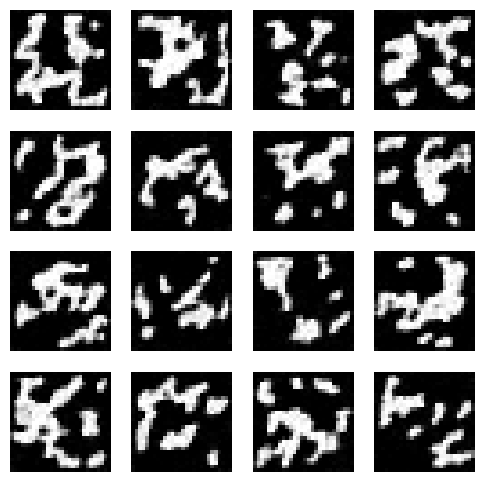

In [19]:
# 从模型中采样生成 16 张图像
samples = sample(model, num_samples=16)

# 创建 4x4 子图网格
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

# 遍历每个子图，显示生成的图像
for i, ax in enumerate(axes.flat):
    # 移除通道维度，转为 numpy，显示灰度图
    ax.imshow(samples[i].cpu().squeeze(), cmap="gray")
    ax.axis("off")          # 隐藏坐标轴

plt.show()                  # 展示图像
